## Hyper-parameter

In [1]:
import os
import random
from collections import defaultdict

import numpy as np

# MDP
# mu and sigma to parameterize the normal distribution for the noisy reward
mu = -0.1
sigma = 1.0
n_action_B = 20  # num action in state B

# Define learning hyperparameters
alpha_schedule = [0.1, 0.001, 1.0]
epsilon_schedule = [0.1, 0.0, 0.98] # 0.98
# epsilon_schedule = [0.1, 0.001, 1.0]
v_factor_schedule = [1.0, 0.001, 1.0]
gamma = 0.99
value_noise = 0.0  # for adding independent noise to the value functions

rbs = 1  # replay buffer size
bs = 1  # batch size
num_repeats = 1288
num_of_episode = 300

# Misc
constant_plot_prob_A_left = {"value": 0.0, "label": "Optimal"}
constant_plot_eval_Q_onpolicy = {"value": 0.0, "label": "Optimal"}
constant_plot_V_Q = {"value": 0.0, "label": "Optimal"}
constant_plot_A_X_Q = {"value": 0.0, "label": "Optimal"}
constant_plot_B_X_Q = {"value": 0.0, "label": "Optimal"}

x_interval = int(num_of_episode / 10)  # for plotting x_ticks

save_path = f"results/MDP(mu{mu}_sigma{sigma}_nB{n_action_B})/value_noise{value_noise}/eps[{epsilon_schedule[0]}_{epsilon_schedule[1]}_{epsilon_schedule[2]}]_gamma{gamma}/RB{rbs}_BS{bs}_nRepeat{num_repeats}_nEpisode{num_of_episode}/"

print(f"save_path: {save_path}")

if not os.path.exists(save_path):
    os.makedirs(save_path)

# note = f"factor={VQ_alpha}, n_episode={num_of_episode}"
note = ""

save_path: results/MDP(mu-0.1_sigma1.0_nB20)/value_noise0.0/eps[0.1_0.0_0.98]_gamma0.99/RB1_BS1_nRepeat1288_nEpisode300/


## Define Env

In [2]:
class Env:
    def __init__(self, nB, mu, sigma):
        self.mu = mu
        self.sigma = sigma
        self.states = list(np.arange(3))
        # self.states = [-5,-4,-3,-2,-1,0]
        self.left = 0
        self.right = 1

        self.nS = len(self.states)
        self.n_action_A = 2
        self.n_action_B = nB  # num action in state B

        self.STATE_A = self.states[-1]
        self.STATE_B = self.states[1]
        self.Terminal = self.states[0]
        self.init_state = self.STATE_A

    def reset(self):
        self.state = self.init_state
        return self.state

    def step(self, action):
        if self.state == self.STATE_B:
            self.state = self.Terminal
            if self.sigma > 0.0:
                reward = np.random.normal(self.mu, self.sigma)
            else:
                reward = self.mu
            return self.state, reward, True
        else:
            assert self.state == self.STATE_A, f"Invalid state {self.state}"
            assert action in [self.left, self.right], "Invalid action"
            if action == self.left:
                self.state -= 1
                return self.state, 0, False
            # elif action == self.right:
            #     self.state += 1
            #     if self.state > self.STATE_A:
            #         self.state = self.Terminal
            #         return self.state, 0, True
            #     else:
            #         return self.state, 0, False
            else:
                self.state = self.Terminal
                return self.state, 0, True

## Create Replay Buffer, Q table, V table

In [3]:
class Buffer:
    def __init__(self, size, batch_size):
        self.obs = np.zeros([size], dtype=np.int32)
        self.n_obs = np.zeros([size], dtype=np.int32)
        self.act = np.zeros([size], dtype=np.int32)
        self.rew = np.zeros([size], dtype=np.float32)
        self.done = np.zeros([size], dtype=bool)
        self.max_size, self.batch_size = size, batch_size
        self.ptr, self.size = 0, 0

    def store(
        self,
        obs: np.ndarray,
        act: np.ndarray,
        rew: float,
        next_obs: np.ndarray,
        done: bool,
    ):
        self.obs[self.ptr] = obs
        self.n_obs[self.ptr] = next_obs
        self.act[self.ptr] = act
        self.rew[self.ptr] = rew
        self.done[self.ptr] = done
        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample_batch(self):
        idxs = np.random.choice(self.size, size=self.batch_size, replace=False)
        return dict(
            obs=self.obs[idxs], n_obs=self.n_obs[idxs], act=self.act[idxs], rew=self.rew[idxs], done=self.done[idxs]
        )

    def __len__(self) -> int:
        return self.size


def init_Q_table(env: Env):
    Q = {
        env.STATE_A: np.zeros([env.n_action_A]),
        env.STATE_B: np.zeros([env.n_action_B]),
        env.Terminal: np.zeros([1]),
    }

    return Q


def init_V_table(env: Env):
    V = np.zeros([env.nS])
    return V




## Define Learner

In [4]:
import random


def select_action(action_values, epsilon):
    if np.random.random() > epsilon:
        value = np.max(action_values)
        action = random.choice(np.argwhere(action_values == value))[0]
    else:
        action = np.random.choice(len(action_values))
    return action

def eval_policy(env, Q, epsilon):
    Q_onpolicy = []
    state = env.reset()
    while True:
        action = select_action(Q[state], epsilon)
        Q_onpolicy.append(Q[state][action])
        next_state, reward, done = env.step(action)
        if done:
            # return mean(Q_onlicy)
            return sum(Q_onpolicy)/len(Q_onpolicy)

def TD_learning_Replay(
    env: Env,
    method:str,
    alpha_schedule:str,
    epsilon_schedule:str,
    v_factor_schedule:str,
    num_of_episode=1000,
    gamma=0.9,
    value_noise=0.0,
    rbs=1,
    bs=1,
):
    epsilon = epsilon_schedule[0]
    alpha = alpha_schedule[0]
    v_factor = v_factor_schedule[0]

    Q = init_Q_table(env)
    V = init_V_table(env)
    buffer = Buffer(size=rbs, batch_size=bs)
    if method == "Double-Q":
        Q2 = init_Q_table(env)

    mean_reward_B = 0
    visit_B = 0

    bool_A_left = np.zeros(num_of_episode)
    bool_A_right = np.zeros(num_of_episode)
    eval_Q_onpolicy = np.zeros(num_of_episode)
    Q_A_left = np.zeros(num_of_episode)
    Q_A_right = np.zeros(num_of_episode)
    maxQ_A = np.zeros(num_of_episode)
    maxQ_B = np.zeros(num_of_episode)
    meanQ_B = np.zeros(num_of_episode)
    episode_rewards = np.zeros(num_of_episode)
    alphas = np.zeros(num_of_episode)
    epsilons = np.zeros(num_of_episode)
    if method == "VQ-Learning":
        Q_onpolicy = np.zeros(num_of_episode)
        V_onpolicy = np.zeros(num_of_episode)
        V_A = np.zeros(num_of_episode)
        V_B = np.zeros(num_of_episode)
        diffVQ_A_left = np.zeros(num_of_episode)

    for num in range(num_of_episode):
        state = env.reset()  # Init S
        episode_reward = 0
        if method == "VQ-Learning":
            mean_V_values = [] # for comparison between onpolicy V and Q for VQ-Learning, this is required as a condition in the proof of convergence
            mean_Q_values = []
        while True:
            if method == "Double-Q":
                Q_values = (Q[state] + Q2[state]) / 2
            else:
                Q_values = Q[state]
            action = select_action(Q_values, epsilon)

            if method == "VQ-Learning":
                mean_V_values.append(V[state])
                mean_Q_values.append(Q[state][action])
            if state == env.STATE_A and action == env.left:
                bool_A_left[num] += 1
            if state == env.STATE_A and action == env.right:
                bool_A_right[num] += 1

            next_state, reward, done = env.step(action)
            buffer.store(state, action, reward, next_state, done)
            if state == env.STATE_B:
                visit_B += 1
                mean_reward_B = (mean_reward_B * (visit_B - 1) + reward) / visit_B
            episode_reward += reward
            if len(buffer) >= buffer.batch_size:
                dict = buffer.sample_batch()
                b_obs, b_act, b_rew, b_nobs, b_done = dict["obs"], dict["act"], dict["rew"], dict["n_obs"], dict["done"]
                b_done = b_done.astype(int)
                for obs, act, rew, nobs, terminated in zip(b_obs, b_act, b_rew, b_nobs, b_done): # terminated is used instead of done, otherwise it causes bug
                    if method == "Q-Learning":
                        q_error = alpha * (rew + gamma * (1 - terminated) * np.max(Q[nobs]) - Q[obs][act])
                        Q[obs][act] += q_error
                    elif method == "VQ-Learning":
                        v_error = (rew + gamma * V[nobs] - V[obs])
                        V[obs] += alpha * v_error
                        error = (1 - v_factor) * (
                            rew + gamma * np.max(Q[nobs]) - Q[obs][act]
                        ) + v_factor * (rew + gamma * V[nobs] - Q[obs][act])
                        Q[obs][act] += alpha * error
                        # Q[state][action] += alpha * (reward + gamma*max( Q[next_state].values() ) - Q[state][action])
                        # Q[state][action] += alpha * (reward + gamma*V[next_state]- Q[state][action]) * factor
                        # Q[state][action] += alpha * ((reward + gamma*max( Q[next_state].values() ) - Q[state][action]) + (reward + gamma*V[next_state]- Q[state][action]))
                    elif method == "Sarsa":
                        action_prime = select_action(Q[nobs], epsilon)
                        Q[obs][act] += alpha * (rew + gamma * Q[nobs][action_prime] - Q[obs][act])
                    elif method == "Expected_Sarsa":
                        max_q = np.max(Q[nobs])
                        mean_q = np.mean(Q[nobs])
                        expected_q = (1 - epsilon) * max_q + epsilon * mean_q
                        Q[obs][act] += alpha * (rew + gamma * expected_q - Q[obs][act])
                        # Q[b_obs, b_act] += alpha * (b_rew + gamma*np.mean(Q[b_nobs], axis=-1) - Q[b_obs, b_act])
                    elif method == "Action_Distribution":
                        rand_next_q = np.random.choice(Q[nobs])
                        Q[obs][act] += alpha * (rew + gamma * rand_next_q - Q[obs][act])
                    elif method == "Double-Q":
                        if np.random.random() >= 0.5:
                            A1 = random.choice(np.argwhere(Q[nobs] == np.max(Q[nobs])))[0]
                            Q[obs][act] += alpha * (rew + gamma * Q2[nobs][A1] - Q[obs][act])
                        else:
                            A2 = random.choice(np.argwhere(Q2[nobs] == np.max(Q2[nobs])))[0]
                            Q2[obs][act] += alpha * (rew + gamma * Q[nobs][A2] - Q2[obs][act])

            if done:
                break
            state = next_state
        if method == "Double-Q":
            Q_A_left[num] = (Q[env.STATE_A][env.left] + Q2[env.STATE_A][env.left]) / 2
            Q_A_right[num] = (Q[env.STATE_A][env.right] + Q2[env.STATE_A][env.right]) / 2
            maxQ_A[num] = (np.max(Q[env.STATE_A] + Q2[env.STATE_A])) / 2
            maxQ_B[num] = (np.max(Q[env.STATE_B] + Q2[env.STATE_B])) / 2
        else:
            Q_A_left[num] = Q[env.STATE_A][env.left]
            Q_A_right[num] = Q[env.STATE_A][env.right]
            maxQ_A[num] = np.max(Q[env.STATE_A])
            maxQ_B[num] = np.max(Q[env.STATE_B])
        meanQ_B[num] = np.sum(Q[env.STATE_B]) / len(Q[env.STATE_B])
        episode_rewards[num] = episode_reward
        alphas[num] = alpha
        epsilons[num] = epsilon
        if method == "VQ-Learning":
            V_onpolicy[num] = sum(mean_V_values)/len(mean_V_values)
            Q_onpolicy[num] = sum(mean_Q_values)/len(mean_Q_values)
            V_A[num] = V[env.STATE_A]
            V_B[num] = V[env.STATE_B]
            diffVQ_A_left[num] = V[env.STATE_A] - Q[env.STATE_A][env.left]
        eval_Q_onpolicy[num] = eval_policy(env, Q, epsilon)

        # hyper-parameters update after each episode
        if epsilon >= epsilon_schedule[1]:
            epsilon *= epsilon_schedule[2]
        if alpha >= alpha_schedule[1]:
            alpha *= alpha_schedule[2]
        if v_factor >= v_factor_schedule[1]:
            v_factor *= v_factor_schedule[2]
        if value_noise > 0.0:
            for state, q_values in Q.items():
                Q[state] = np.random.normal(q_values, value_noise)
            if method == "Double-Q":
                for state, q_values in Q2.items():
                    Q2[state] = np.random.normal(q_values, value_noise)
            V = np.random.normal(V, value_noise)

    output = {
        "bool_A_left": bool_A_left,
        "bool_A_right": bool_A_right,
        "Q_A_left": Q_A_left,
        "Q_A_right": Q_A_right,
        "maxQ_A": maxQ_A,
        "maxQ_B": maxQ_B,
        "meanQ_B": meanQ_B,
        "episode_rewards": episode_rewards,
        "alphas": alphas,
        "epsilons": epsilons,
        "eval_Q_onpolicy": eval_Q_onpolicy,
        # "Q": Q,
    }
    if method == "VQ-Learning":
        output["Q_onpolicy"] = Q_onpolicy
        output["V_onpolicy"] = V_onpolicy
        output["V_A"] = V_A
        output["V_B"] = V_B
        output["diffVQ_A_left"] = diffVQ_A_left
    return output


# alpha_scope = [0.1, 0.001, 1.0]
# epsilon_scope = [0.1, 0.001, 1.0]
# v_factor_scope=[1.0, 0.001, 1.0]
# gamma = 0.9

# env = Env(mu=-0.1, sigma=1.0, nB=30)

# output = TD_learning_Replay(env, method='Q-Learning', alpha_scope=[0.1, 0.001, 1.0], epsilon_scope=[0.1, 0.001, 1.0], v_factor_scope=v_factor_scope, num_of_episode=num_of_episode, gamma=gamma)

## Learning

In [19]:
# from tqdm.notebook import tqdm
from tqdm import tqdm

env = Env(mu=mu, sigma=sigma, nB=n_action_B)

methods_handle = ['Q', 'Q2', 'SARSA', 'ESARSA', 'VQ']
methods_handle_to_name = {
    'Q': 'Q-Learning',
    'Q2': 'Double-Q',
    'SARSA': 'Sarsa',
    'ESARSA': 'Expected_Sarsa',
    'VQ': 'VQ-Learning'
}

metrics = defaultdict(lambda: np.zeros((num_repeats, num_of_episode)))

# metrics = {}
# for handle in methods_handle:
#     metrics[f"prob_A_left_{handle}"] = np.zeros((num_repeats, num_of_episode))
#     metrics[f"prob_A_right_{handle}"] = np.zeros((num_repeats, num_of_episode))
#     metrics[f"Q_A_left_{handle}"] = np.zeros((num_repeats, num_of_episode))
#     metrics[f"Q_A_right_{handle}"] = np.zeros((num_repeats, num_of_episode))
#     metrics[f"maxQ_A_{handle}"] = np.zeros((num_repeats, num_of_episode))
#     metrics[f"maxQ_B_{handle}"] = np.zeros((num_repeats, num_of_episode))
#     metrics[f"meanQ_B_{handle}"] = np.zeros((num_repeats, num_of_episode))
#     metrics[f"eval_Q_onpolicy_{handle}"] = np.zeros((num_repeats, num_of_episode))
#     metrics[f"episode_rewards_{handle}"] = np.zeros((num_repeats, num_of_episode))
#     if handle == 'VQ':
#         metrics[f"V_onpolicy_{handle}"] = np.zeros((num_repeats, num_of_episode))
#         metrics[f"Q_onpolicy_{handle}"] = np.zeros((num_repeats, num_of_episode))
#         metrics[f"V_A_{handle}"] = np.zeros((num_repeats, num_of_episode))
#         metrics[f"V_B_{handle}"] = np.zeros((num_repeats, num_of_episode))
#         metrics[f"diffVQ_A_left_{handle}"] = np.zeros((num_repeats, num_of_episode))

for num in tqdm(range(num_repeats)):
    outs = {}
    for handle, method_name in methods_handle_to_name.items():
        out = TD_learning_Replay(
            env,
            method_name,
            alpha_schedule,
            epsilon_schedule=epsilon_schedule,
            v_factor_schedule=v_factor_schedule,
            num_of_episode=num_of_episode,
            gamma=gamma,
            value_noise=value_noise,
            rbs=rbs,
            bs=bs,
        )
        outs[method_name] = out

        metrics[f"prob_A_left_{handle}"][num] = out["bool_A_left"]
        metrics[f"prob_A_right_{handle}"][num] = out["bool_A_right"]
        metrics[f"Q_A_left_{handle}"][num] = out["Q_A_left"]
        metrics[f"Q_A_right_{handle}"][num] = out["Q_A_right"]
        metrics[f"maxQ_A_{handle}"][num] = out["maxQ_A"]
        metrics[f"maxQ_B_{handle}"][num] = out["maxQ_B"]
        metrics[f"meanQ_B_{handle}"][num] = out["meanQ_B"]
        metrics[f"eval_Q_onpolicy_{handle}"][num] = out["eval_Q_onpolicy"]
        metrics[f"episode_rewards_{handle}"][num] = out["episode_rewards"]
        metrics[f"alphas_{handle}"][num] = out["alphas"]
        metrics[f"epsilons_{handle}"][num] = out["epsilons"]
        if handle == 'VQ':
            metrics[f"V_onpolicy_{handle}"][num] = out["V_onpolicy"]
            metrics[f"Q_onpolicy_{handle}"][num] = out["Q_onpolicy"]
            metrics[f"V_A_{handle}"][num] = out["V_A"]
            metrics[f"V_B_{handle}"][num] = out["V_B"]
            metrics[f"diffVQ_A_left_{handle}"][num] = out["diffVQ_A_left"]

#save metrics, metics is a dict of np arrays
np.savez(os.path.join(save_path, "metrics.npz"),**metrics)

100%|██████████| 1288/1288 [00:49<00:00, 25.80it/s]


## Load metrics from npz file

In [20]:
save_path

'results/MDP(mu-0.1_sigma1.0_nB20)/value_noise0.0/eps[0.1_0.0_0.98]_gamma0.99/RB1_BS1_nRepeat1288_nEpisode300/'

In [21]:
#load metrics
# metrics = np.load(os.path.join(save_path, "metrics.npz"))
# print(metrics["eval_Q_onpolicy_Q2"][:3])


## Define plotting functions

In [22]:
import matplotlib.pyplot as plt


def plot_data_with_label(data, label, std=True):
    x_horizon = data.shape[1]
    plt.plot(range(x_horizon), data.mean(axis=0), "-", label=label)
    if std:
        plt.fill_between(
            range(x_horizon),
            data.mean(axis=0) - data.std(axis=0) / 2,
            data.mean(axis=0) + data.std(axis=0) / 2,
            alpha=0.2,
        )

def plot_prob_A_left(
    prob_A_left_Q, prob_A_left_Q2, prob_A_left_SARSA, prob_A_left_ESARSA, prob_A_left_VQ, constant:dict | None =None, std=False, note="", legend_loc="best", show=True, save_path=None
):
    plt.ylabel("P(left|A)", fontsize=13)
    plt.xlabel("Episodes", fontsize=13)
    x_horizon = prob_A_left_Q.shape[1]
    x_ticks = np.arange(0, x_horizon + 1, x_interval)
    y_ticks = np.arange(0, 1.1, 0.1)
    plt.xticks(x_ticks, fontsize=13)
    # plt.yticks(y_ticks,['0%','10%','20%','30%','40%','50%','60%','70%','80%','90%','100%'], fontsize=15)
    plt.yticks(y_ticks, ["0.0", "0.1", "0.2", "0.3", "0.4", "0.5", "0.6", "0.7", "0.8", "0.9", "1.0"], fontsize=15)
    if prob_A_left_Q is not None:
        plot_data_with_label(prob_A_left_Q, "Q-learning", std)
    if prob_A_left_Q2 is not None:
        plot_data_with_label(prob_A_left_Q2, "Double Q-learning", std)
    if prob_A_left_SARSA is not None:
        plot_data_with_label(prob_A_left_SARSA, "SARSA", std)
    if prob_A_left_ESARSA is not None:
        plot_data_with_label(prob_A_left_ESARSA, "Expected SARSA", std)
    if prob_A_left_VQ is not None:
        plot_data_with_label(prob_A_left_VQ, "VQ-learning", std)
    if constant is not None:
        plt.plot(np.ones(x_horizon) * constant['value'], '--', color='black', label=constant['label'])
    # plt.title('Comparison of probability of left actions from A' + note)
    plt.legend(
    fontsize=12,
    # markerscale=0.8,
    # handlelength=1.4,
    loc=legend_loc,
    ncol=1
    )
    plt.grid()
    if save_path is not None:
        plt.savefig(f"{save_path}/prob_A_left.png", dpi=200)
    if show:
        plt.show()
    plt.close()

def plot_A_X_Q(A_Q, A_Q2, A_SARSA, A_ESARSA, A_VQ, constant:dict | None =None, y_label="Q(A, left)", std=False, note="", legend_loc="best", show=True, save_path=None):
    '''
    A means state A; X refers to left or right action or max
    '''
    plt.ylabel(y_label)
    plt.xlabel("Episodes")
    x_horizon = A_Q.shape[1]
    x_ticks = np.arange(0, x_horizon + 1, x_interval)
    # y_ticks = np.arange(0,1.1,0.1)
    plt.xticks(x_ticks)
    # plt.yticks(y_ticks,['0%','10%','20%','30%','40%','50%','60%','70%','80%','90%','100%'])
    if A_Q is not None:
        plot_data_with_label(A_Q, "Q-Learning", std)
    if A_Q2 is not None:
        plot_data_with_label(A_Q2, "Double Q-Learning", std)
    if A_SARSA is not None:
        plot_data_with_label(A_SARSA, "SARSA", std)
    if A_ESARSA is not None:
        plot_data_with_label(A_ESARSA, "Expected SARSA", std)
    if A_VQ is not None:
        plot_data_with_label(A_VQ, "VQ Learning", std)
    if constant is not None:
        plt.plot(np.ones(num_of_episode) * constant["value"], '--', color='black', label=constant["label"])
    # plt.title(f"Comparison of {y_label}, {note}")
    plt.legend(
    fontsize=12,
    # markerscale=0.8,
    # handlelength=1.4,
    loc=legend_loc,
    ncol=1
    )
    plt.grid()
    if save_path is not None:
        # y_label = y_label.replace(',', '_')
        plt.savefig(f"{save_path}/{y_label}.png", dpi=200)
    if show:
        plt.show()
    plt.close()

def plot_B_X_Q(B_Q, B_Q2, B_SARSA, B_ESARSA, B_VQ, constant:dict | None =None, y_label="", std=False, note="", legend_loc="best", show=True, save_path=None):
    '''
    B means state B; X refers to mean or max
    '''
    plt.ylabel(y_label)
    plt.xlabel("Episodes")
    x_horizon = B_Q.shape[1]
    x_ticks = np.arange(0, x_horizon + 1, x_interval)
    # y_ticks = np.arange(0,1.1,0.1)
    plt.xticks(x_ticks)
    # plt.yticks(y_ticks,['0%','10%','20%','30%','40%','50%','60%','70%','80%','90%','100%'])
    if B_Q is not None:
        plot_data_with_label(B_Q, "Q-Learning", std)
    if B_Q2 is not None:
        plot_data_with_label(B_Q2, "Double Q-Learning", std)
    if B_SARSA is not None:
        plot_data_with_label(B_SARSA, "SARSA", std)
    if B_ESARSA is not None:
        plot_data_with_label(B_ESARSA, "Expected SARSA", std)
    if B_VQ is not None:
        plot_data_with_label(B_VQ, "VQ Learning", std)
    if constant is not None:
        plt.plot(np.ones(x_horizon) * constant["value"], '--', color='black', label=constant["label"])
    # plt.title(f"Comparison of {y_label}, {note}")
    plt.legend(
    fontsize=12,
    # markerscale=0.8,
    # handlelength=1.4,
    loc=legend_loc,
    ncol=1
    )
    plt.grid()
    if save_path is not None:
        plt.savefig(f"{save_path}/{y_label}.png", dpi=200)
    if show:
        plt.show()
    plt.close()

def plot_eval_Q_onpolicy(eval_Q_onpolicy_Q, eval_Q_onpolicy_Q2, eval_Q_onpolicy_SARSA, eval_Q_onpolicy_ESARSA, eval_Q_onpolicy_VQ, constant:dict | None =None, y_label="Q value estimates", std=False, note="", legend_loc="best", show=True, save_path=None):
    plt.ylabel(y_label)
    plt.xlabel("Episodes")
    x_horizon = eval_Q_onpolicy_Q.shape[1]
    x_ticks = np.arange(0, x_horizon + 1, x_interval)
    # y_ticks = np.arange(0,1.1,0.1)
    plt.xticks(x_ticks)
    # plt.yticks(y_ticks,['0%','10%','20%','30%','40%','50%','60%','70%','80%','90%','100%'])
    if eval_Q_onpolicy_Q is not None:
        plot_data_with_label(eval_Q_onpolicy_Q, "Q-Learning", std)
    if eval_Q_onpolicy_Q2 is not None:
        plot_data_with_label(eval_Q_onpolicy_Q2, "Double Q-Learning", std)
    if eval_Q_onpolicy_SARSA is not None:
        plot_data_with_label(eval_Q_onpolicy_SARSA, "SARSA", std)
    if eval_Q_onpolicy_ESARSA is not None:
        plot_data_with_label(eval_Q_onpolicy_ESARSA, "Expected SARSA", std)
    if eval_Q_onpolicy_VQ is not None:
        plot_data_with_label(eval_Q_onpolicy_VQ, "VQ Learning", std)
    if constant is not None:
        plt.plot(np.ones(x_horizon) * constant["value"], '--', color='black', label=constant["label"])
    # plt.title(f"Comparison of {y_label}, {note}")
    plt.legend(
    fontsize=12,
    # markerscale=0.8,
    # handlelength=1.4,
    loc=legend_loc,
    ncol=1
    )
    plt.grid()
    if save_path is not None:
        plt.savefig(f"{save_path}/{y_label}.png", dpi=200)
    if show:
        plt.show()
    plt.close()

def plot_V_Q(V_onpolicy_VQ, Q_onpolicy_VQ, constant:dict | None =None, y_label="Estimates of V and Q", std=False, note="", legend_loc="best", show=True, save_path=None):
    plt.ylabel(y_label)
    plt.xlabel("Episodes")
    x_horizon = V_onpolicy_VQ.shape[1]
    x_ticks = np.arange(0, x_horizon + 1, x_interval)
    # y_ticks = np.arange(0,1.1,0.1)
    plt.xticks(x_ticks)
    # plt.yticks(y_ticks,['0%','10%','20%','30%','40%','50%','60%','70%','80%','90%','100%'])
    plot_data_with_label(V_onpolicy_VQ, "V(s)", std)
    plot_data_with_label(Q_onpolicy_VQ, "Q(s,a)", std)

    if constant is not None:
        plt.plot(np.ones(num_of_episode) * constant["value"], '--', color='black', label=constant["label"])
    # plt.title(f"Comparison of {y_label}, {note}")
    plt.legend(
    fontsize=12,
    # markerscale=0.8,
    # handlelength=1.4,
    loc=legend_loc,
    ncol=1
    )
    plt.grid()
    if save_path is not None:
        plt.savefig(f"{save_path}/{y_label}.png", dpi=200)
    if show:
        plt.show()
    plt.close()

def plot_V(V_A, V_B, constant:dict | None =None, y_label="Estimates of V for A and B", std=False, note="", legend_loc="best", show=True, save_path=None):
    plt.ylabel(y_label)
    plt.xlabel("Episodes")
    x_horizon = V_A.shape[1]
    x_ticks = np.arange(0, x_horizon + 1, x_interval)
    # y_ticks = np.arange(0,1.1,0.1)
    plt.xticks(x_ticks)
    # plt.yticks(y_ticks,['0%','10%','20%','30%','40%','50%','60%','70%','80%','90%','100%'])
    plot_data_with_label(V_A, "V(A)", std)
    plot_data_with_label(V_B, "V(B)", std)

    if constant is not None:
        plt.plot(np.ones(num_of_episode) * constant["value"], '--', color='black', label=constant["label"])
    # plt.title(f"Comparison of {y_label}, {note}")
    plt.legend(
    fontsize=12,
    # markerscale=0.8,
    # handlelength=1.4,
    loc=legend_loc,
    ncol=1
    )
    plt.grid()
    if save_path is not None:
        plt.savefig(f"{save_path}/{y_label}.png", dpi=200)
    if show:
        plt.show()
    plt.close()

## Plot probability if take action left on state A

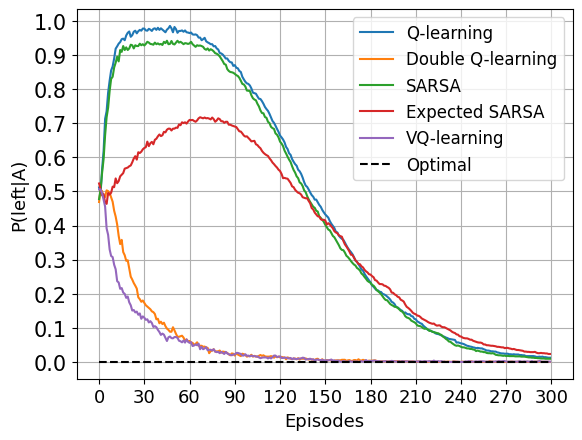

In [23]:
plot_prob_A_left(
    metrics["prob_A_left_Q"],
    metrics["prob_A_left_Q2"],
    metrics["prob_A_left_SARSA"],
    metrics["prob_A_left_ESARSA"],
    metrics["prob_A_left_VQ"],
    constant=constant_plot_prob_A_left,
    std=False,
    note=note,
    legend_loc="upper right",
    save_path=save_path,
)

## Plot compare V Q

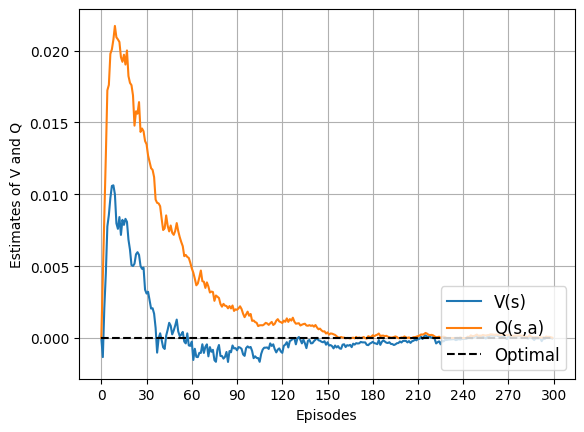

In [24]:
plot_V_Q(
    metrics["V_onpolicy_VQ"],
    metrics["Q_onpolicy_VQ"],
    constant=constant_plot_V_Q,
    std=False,
    y_label="Estimates of V and Q",
    note=note,
    legend_loc="lower right",
    save_path=save_path,
)

## Plot A Max Q

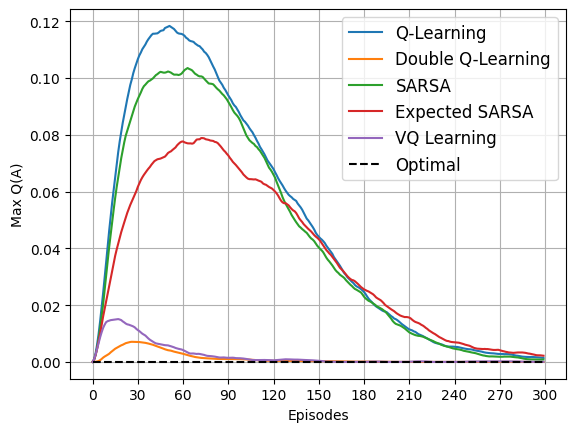

In [25]:
plot_A_X_Q(
    metrics["maxQ_A_Q"],
    metrics["maxQ_A_Q2"],
    metrics["maxQ_A_SARSA"],
    metrics["maxQ_A_ESARSA"],
    metrics["maxQ_A_VQ"],
    constant=constant_plot_A_X_Q,
    y_label="Max Q(A)",
    std=False,
    note=note,
    legend_loc="upper right",
    save_path=save_path,
)

## Plot B Max Q

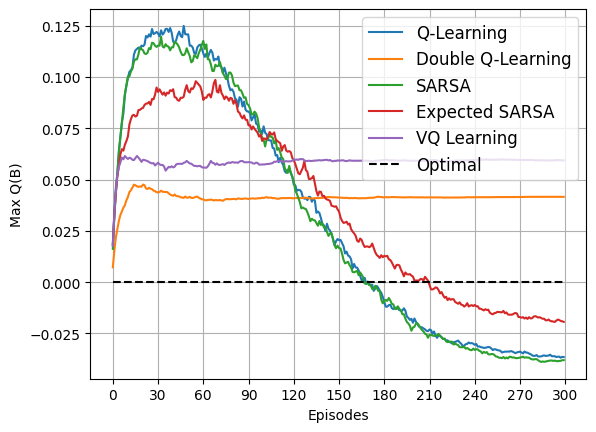

In [26]:
plot_B_X_Q(
    metrics["maxQ_B_Q"],
    metrics["maxQ_B_Q2"],
    metrics["maxQ_B_SARSA"],
    metrics["maxQ_B_ESARSA"],
    metrics["maxQ_B_VQ"],
    constant=constant_plot_B_X_Q,
    y_label="Max Q(B)",
    std=False,
    note=note,
    legend_loc="upper right",
    save_path=save_path,
)

## Plot eval Q onpolicy

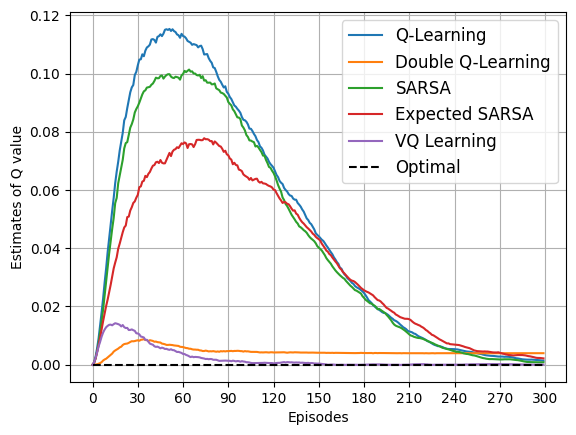

In [27]:
plot_eval_Q_onpolicy(
    metrics["eval_Q_onpolicy_Q"],
    metrics["eval_Q_onpolicy_Q2"],
    metrics["eval_Q_onpolicy_SARSA"],
    metrics["eval_Q_onpolicy_ESARSA"],
    metrics["eval_Q_onpolicy_VQ"],
    constant=constant_plot_eval_Q_onpolicy,
    y_label="Estimates of Q value",
    std=False,
    note=note,
    legend_loc="upper right",
    save_path=save_path,
)

## Plot Q(A, left) and Q(A, right)

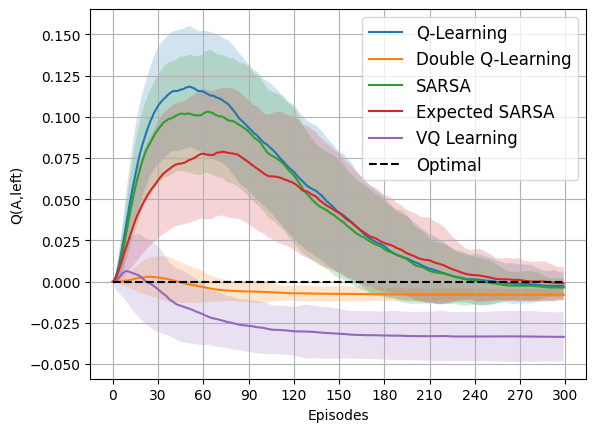

In [28]:
plot_A_X_Q(
    metrics["Q_A_left_Q"],
    metrics["Q_A_left_Q2"],
    metrics["Q_A_left_SARSA"],
    metrics["Q_A_left_ESARSA"],
    metrics["Q_A_left_VQ"],
    constant=constant_plot_A_X_Q,
    y_label="Q(A,left)",
    std=True,
    note=note,
    legend_loc="upper right",
    save_path=save_path,
)

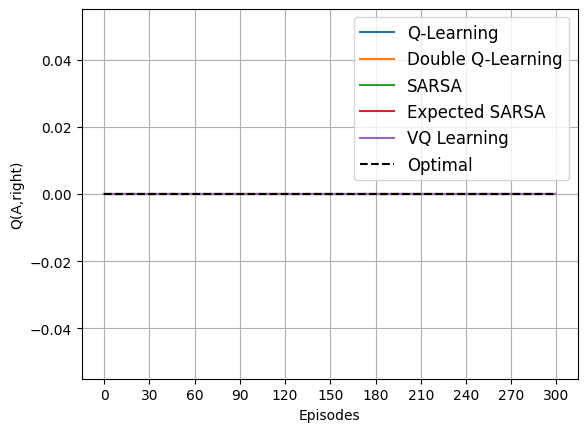

In [29]:
plot_A_X_Q(
    metrics["Q_A_right_Q"],
    metrics["Q_A_right_Q2"],
    metrics["Q_A_right_SARSA"],
    metrics["Q_A_right_ESARSA"],
    metrics["Q_A_right_VQ"],
    constant=constant_plot_A_X_Q,
    y_label="Q(A,right)",
    std=False,
    note=note,
    save_path=save_path,
)

## Plot V(A) and V(B)

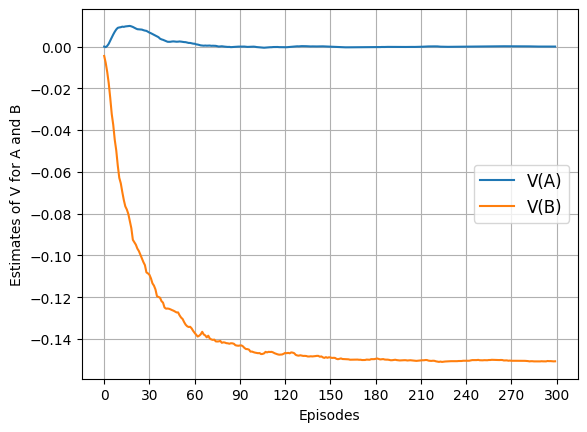

In [30]:
plot_V(
    metrics["V_A_VQ"],
    metrics["V_B_VQ"],
    constant=None,
    y_label="Estimates of V for A and B",
    std=False,
    note=note,
    save_path=save_path,
)

## Plot alpha

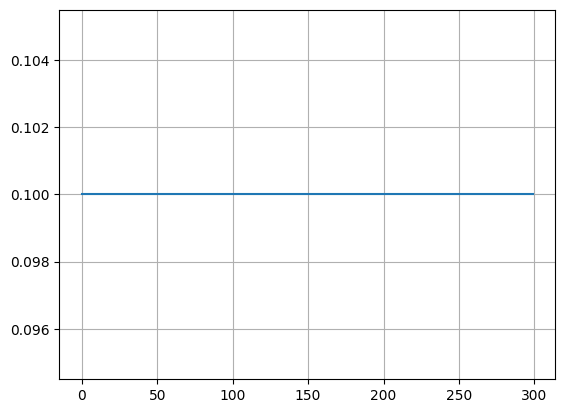

In [31]:
plot_data_with_label(metrics['alphas_Q'], "Q-learning", std=False)
plt.grid()

## Plot epsilon

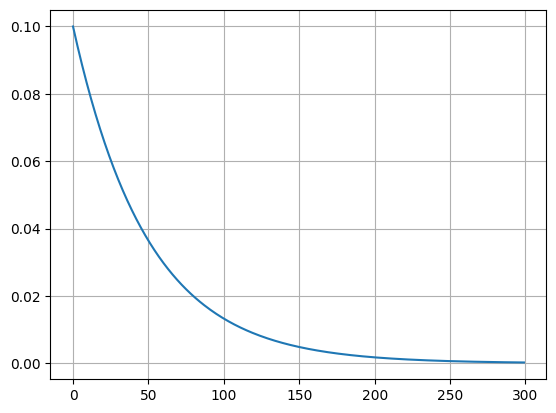

In [32]:
plot_data_with_label(metrics['epsilons_Q'], "Q-learning", std=False)
plt.grid()